In [36]:
import json
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import ConcatDataset, DataLoader
from torch.optim import AdamW
import sys
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample

# set path to project root and import custom classes and functions
project_root = Path.cwd() / "../../../"
sys.path.append(str(project_root.resolve()))
from utils.classification import StanceNLIDataset, train_bert
from utils.evaluation import evaluate_nli_stance

# set seed and specify the device
seed = 0
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Code running on: {device}")

Code running on: mps


In [16]:
# load main data and hyperparameter tuning results
with open(project_root / "01_data/classification/training_validation_sets/stance/training_set.json", "r") as f:
    data = json.load(f)

# load the results from hyperparameter tuning
with open(project_root / "04_classification_models/stance_classification/bert_nli/hyperparameter_tuning_results/ht_bert_nli_stance.json", "r") as f:
    hyperparameter_tuning_results = json.load(f)

# set the model name
model_name = "MoritzLaurer/deberta-v3-base-zeroshot-v2.0"

In [17]:
epochs = hyperparameter_tuning_results[model_name]["best_epoch"]
lr = hyperparameter_tuning_results[model_name]["best_params"]["lr"]
batch_size = hyperparameter_tuning_results[model_name]["best_params"]["batch_size"]
weight_decay = hyperparameter_tuning_results[model_name]["best_params"]["weight_decay"]

# define the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# create cross-validation object for 5 folds
k = 5
kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
all_labels = [item[0]["stance"] for item in data]

# lists for all true and predicted labels
all_true_labels = []
all_pred_labels = []

# dict for all misclassified stances
misclassified_stances = {}

# randomly split the training data into 5 folds and loop over them
for fold, (train_idx, val_idx) in enumerate(kf.split(data, all_labels)):

    print(f"\nFold number: {fold + 1}")

    # create the model
    model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    label_to_id = model.config.label2id

    # create the training and validation fold based on the provided indices
    train_fold_data = [data[i] for i in train_idx]
    val_fold_data = [data[i] for i in val_idx]

    # unpack validation data (augmentations are not needed)
    val_data = [task[0] for task in val_fold_data]

    # get the original training data
    train_data_original = [task[0] for task in train_fold_data]
    train_dataset = StanceNLIDataset(train_data_original, tokenizer, max_len=128, label2id=label_to_id)
            
    # oversample minority classes to a certain proportion and create datasets
    neg_ann = [r for r in train_fold_data if r[0]["stance"] == "neg"]
    neg_extra = resample(neg_ann, replace=False, n_samples=int(len(neg_ann)*0.5), random_state=0)
    train_data_neg_aug = [task[2] for task in neg_extra]
    train_dataset_neg_aug = StanceNLIDataset(train_data_neg_aug, tokenizer, max_len=128, label2id=label_to_id)
    train_dataset_balanced = ConcatDataset([train_dataset, train_dataset_neg_aug])

    # create the data loader
    train_dataloader = DataLoader(train_dataset_balanced, batch_size=batch_size, shuffle=True)

    # train the model with the optimal configuration
    train_bert(train_dataloader, model, optimizer, epochs, device, which_task="stance")

    # run evaluation
    true_labels, pred_labels = evaluate_nli_stance(
        model=model, data=val_data, tokenizer=tokenizer, device=device
        )
    
    # store errors
    for idx, (pred, true) in enumerate(zip(pred_labels, true_labels)):
        if pred != true:
            key = f"{true}-{pred}"
            false_pred = {
                "sentence": val_data[idx]["sentence"],
                "mention": val_data[idx]["group"],
                "gold_stance": true,
                "pred_stance": pred
            }
            misclassified_stances.setdefault(key, []).append(false_pred)
    
    # extend all true and pred lists
    all_true_labels.extend(true_labels)
    all_pred_labels.extend(pred_labels)

# export the dictionary
with open(project_root / "04_classification_models/stance_classification/bert_nli/error_analysis_results/all_error_stances.json", "w") as f:
    json.dump(misclassified_stances, f, indent=4)


Fold number: 1
Epoch 1/4


Training: 100%|██████████| 444/444 [04:06<00:00,  1.80it/s, loss=0.0913]


Average training loss: 0.2970
Epoch 2/4


Training: 100%|██████████| 444/444 [04:05<00:00,  1.81it/s, loss=0.0152]  


Average training loss: 0.1185
Epoch 3/4


...

Average training loss: 0.1283
Epoch 3/4


Training: 100%|██████████| 444/444 [04:04<00:00,  1.82it/s, loss=0.00134] 


Average training loss: 0.0495
Epoch 4/4


Training: 100%|██████████| 444/444 [04:04<00:00,  1.82it/s, loss=0.000382]


Average training loss: 0.0249


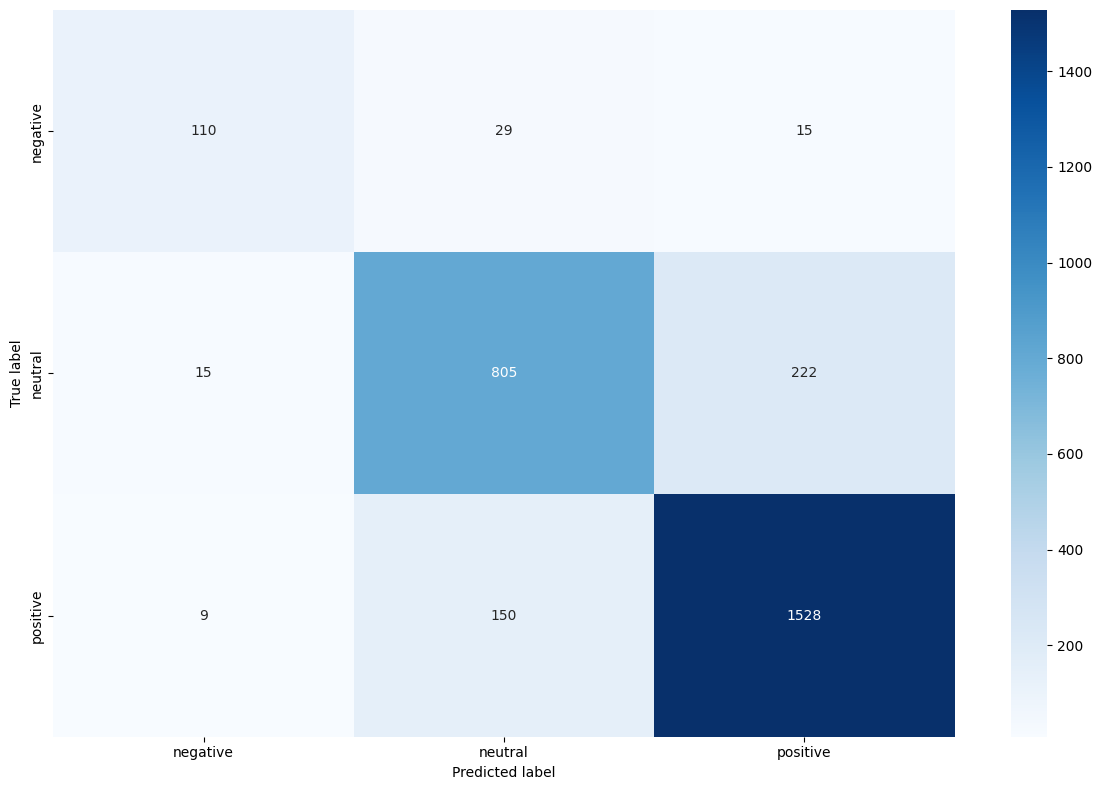

In [21]:
# create confusion matrix as a dataframe
label_remap = {
    "neg": "negative",
    "neutral": "neutral",
    "pos": "positive"
}
all_true_labels = [label_remap[label] for label in all_true_labels]
all_pred_labels = [label_remap[label] for label in all_pred_labels]

labels = sorted(list(set(all_true_labels)))
cm = confusion_matrix(
    all_true_labels,
    all_pred_labels,
    labels=labels
)
cm_row = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_col = cm.astype(float) / cm.sum(axis=0, keepdims=True)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_row_df = pd.DataFrame(cm_row, index=labels, columns=labels)
cm_col_df = pd.DataFrame(cm_col, index=labels, columns=labels)

# save all confusion matrices
cm_df.to_csv(project_root / "04_classification_models/stance_classification/bert_nli/error_analysis_results/cm_raw_counts.csv", index=False)
cm_row_df.to_csv(project_root / "04_classification_models/stance_classification/bert_nli/error_analysis_results/cm_recall.csv", index=False)
cm_col_df.to_csv(project_root / "04_classification_models/stance_classification/bert_nli/error_analysis_results/cm_precision.csv", index=False)

# plot it
plt.figure(figsize=(12, 8))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

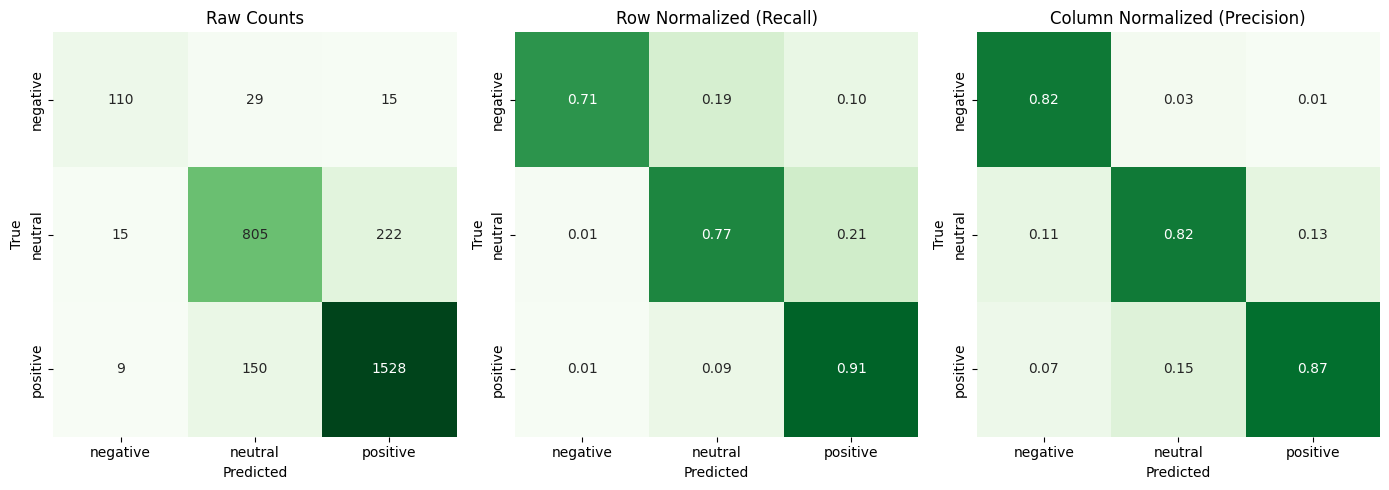

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[0],
    cbar=False
)
axes[0].set_title("Raw Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_row_df,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    ax=axes[1],
    cbar=False
)
axes[1].set_title("Row Normalized (Recall)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

sns.heatmap(
    cm_col_df,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    ax=axes[2],
    cbar=False
)
axes[2].set_title("Column Normalized (Precision)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

In [39]:
# get the most frequent confusion directions
confusions = []

for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j:  # ignore correct predictions
            confusions.append({
                "true": true_label,
                "pred": pred_label,
                "count": cm[i, j]
            })

# sort by raw frequency descending and show top three
confusions = list(sorted(confusions, key=lambda x: x["count"], reverse=True))
print(confusions[0:3])

# sample within these categories
sample_neutral_pos = random.sample(misclassified_stances["neutral-pos"], min(50, len(misclassified_stances["neutral-pos"])))
sample_pos_neutral = random.sample(misclassified_stances["pos-neutral"], min(50, len(misclassified_stances["pos-neutral"])))
sample_neg_neutral = random.sample(misclassified_stances["neg-neutral"], min(50, len(misclassified_stances["neg-neutral"])))

[{'true': 'neutral', 'pred': 'positive', 'count': 222}, {'true': 'positive', 'pred': 'neutral', 'count': 150}, {'true': 'negative', 'pred': 'neutral', 'count': 29}]


In [42]:
sample_neg_neutral

[{'sentence': 'It is one of the reasons why I was very clear yesterday when I did a television interview and set out the security arrangements that we have in place in relation to refugees, so that people can set aside concerns and understand that there are proper security arrangements.',
  'mention': 'refugees',
  'gold_stance': 'neg',
  'pred_stance': 'neutral'},
 {'sentence': 'He did not refer, for instance, to the ITV documentary that was broadcast recently that showed offenders abusing community payback and problems with supervision.',
  'mention': 'offenders',
  'gold_stance': 'neg',
  'pred_stance': 'neutral'},
 {'sentence': 'While Labour was in power, the number of foreign prisoners more than doubled, at great expense to the taxpayer.',
  'mention': 'foreign prisoners',
  'gold_stance': 'neg',
  'pred_stance': 'neutral'},
 {'sentence': 'There are 6,100 tariff-expired offenders serving indeterminate sentences, at a cost, I estimate, of £200 million annually.',
  'mention': 'tari